In [1]:
# !pip install opencv-python pillow pytesseract numpy scipy --quiet

In [2]:
import cv2
import numpy as np
import pytesseract
import json
from PIL import Image
from scipy.ndimage import uniform_filter1d
from IPython.display import display, Image as IPImage
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

print('Tesseract version:', pytesseract.get_tesseract_version())

Tesseract version: 5.5.2


Loaded: test.avif  (1024×783 px)


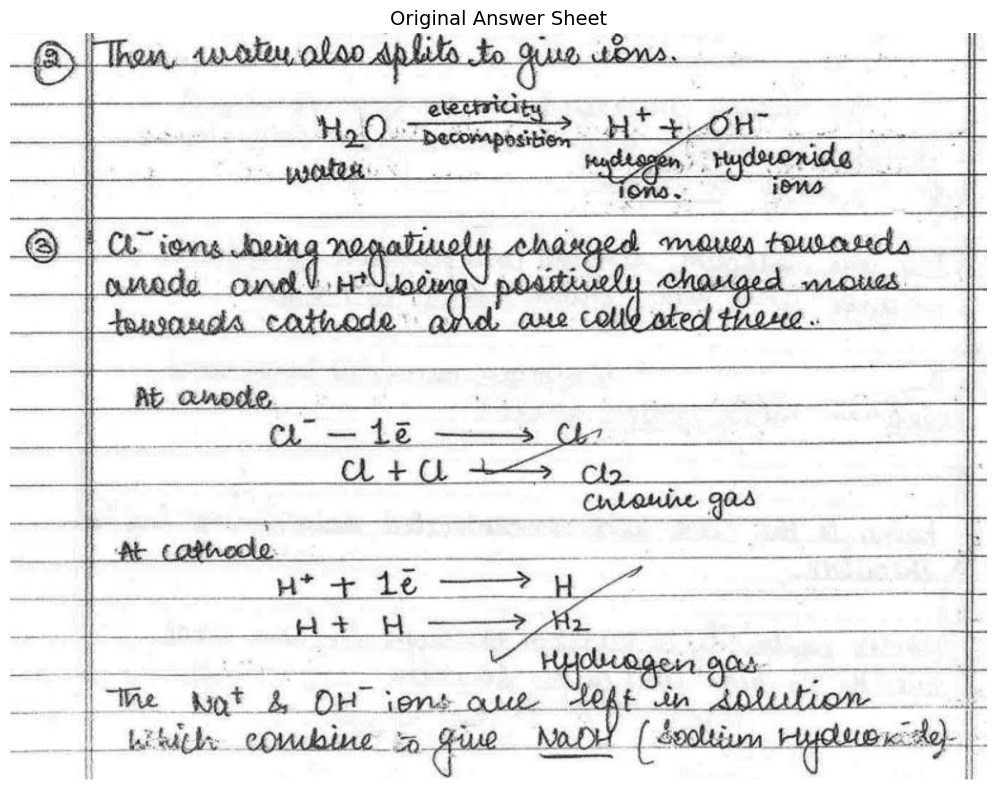

In [3]:
IMAGE_PATH = "test.avif"
OUTPUT_PATH = "annotated_sheet.png"

img = cv2.imread(IMAGE_PATH)
if img is None:
    raise FileNotFoundError(f"Could not load: {IMAGE_PATH}")

print(f"Loaded: {IMAGE_PATH}  ({img.shape[1]}×{img.shape[0]} px)")

plt.figure(figsize=(12, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original Answer Sheet", fontsize=14)
plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
MIN_HEIGHT      = 40
MIN_WIDTH_RATIO = 0.3
GAP_TOLERANCE   = 20


def preprocess(img):
    gray   = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray   = cv2.GaussianBlur(gray, (3, 3), 0)
    binary = cv2.adaptiveThreshold(
        gray, 255,
        cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV,
        blockSize=25, C=10
    )
    return binary


def detect_answer_blocks(img, min_height=MIN_HEIGHT,
                          min_width_ratio=MIN_WIDTH_RATIO,
                          gap_tolerance=GAP_TOLERANCE):
    binary     = preprocess(img)
    h, w       = binary.shape
    projection = np.sum(binary, axis=1).astype(float)

    proj_smooth = uniform_filter1d(projection, size=gap_tolerance)
    threshold   = proj_smooth.max() * 0.02

    in_block, start, bands = False, 0, []
    for i, val in enumerate(proj_smooth):
        if val > threshold and not in_block:
            start, in_block = i, True
        elif val <= threshold and in_block:
            bands.append((start, i))
            in_block = False
    if in_block:
        bands.append((start, h))

    min_w, blocks = int(w * min_width_ratio), []
    for (y1, y2) in bands:
        if y2 - y1 < min_height:
            continue
        col_sum      = np.sum(binary[y1:y2, :], axis=0)
        nonzero_cols = np.where(col_sum > 0)[0]
        if len(nonzero_cols) == 0:
            continue
        x1 = max(0, int(nonzero_cols[0])  - 10)
        x2 = min(w, int(nonzero_cols[-1]) + 10)
        if x2 - x1 < min_w:
            continue
        blocks.append((x1, y1, x2, y2))

    return blocks


blocks = detect_answer_blocks(img)
print(f"Detected {len(blocks)} answer block(s):")
for i, b in enumerate(blocks):
    print(f"  Block {i+1}: x1={b[0]}, y1={b[1]}, x2={b[2]}, y2={b[3]}")

Detected 1 answer block(s):
  Block 1: x1=0, y1=0, x2=1024, y2=783


In [5]:
def ocr_block(img, x1, y1, x2, y2):
    padding = 8
    h, w    = img.shape[:2]
    crop    = img[
        max(0, y1 - padding): min(h, y2 + padding),
        max(0, x1 - padding): min(w, x2 + padding),
    ]


    ch, cw = crop.shape[:2]
    scale  = 2.5 if (ch < 100 or cw < 300) else (1.8 if ch < 200 else 1.0)
    if scale > 1.0:
        crop = cv2.resize(crop, None, fx=scale, fy=scale,
                        interpolation=cv2.INTER_CUBIC)

    pil_crop = Image.fromarray(cv2.cvtColor(crop, cv2.COLOR_BGR2RGB))
    config   = "--oem 3 --psm 6 -l eng"
    return pytesseract.image_to_string(pil_crop, config=config).strip()


results = []
for idx, (x1, y1, x2, y2) in enumerate(blocks):
    text = ocr_block(img, x1, y1, x2, y2)
    results.append({"block": idx + 1,
                    "bbox": {"x1": x1, "y1": y1, "x2": x2, "y2": y2},
                    "text": text})

sep = "─" * 60
print(sep)
for r in results:
    print(f"Answer {r['block']}")
    print(r['text'] if r['text'] else "(no text detected)")
    print(sep)

────────────────────────────────────────────────────────────
Answer 1
(@> | Thea, Anau ola db Lily to We won
| me amet
| > a+U+3 a |.
4. NE se Ee I Secor a2 hisfem 2-9: :
— 1 ee sania ‘ enim (dein tysuo nde
────────────────────────────────────────────────────────────


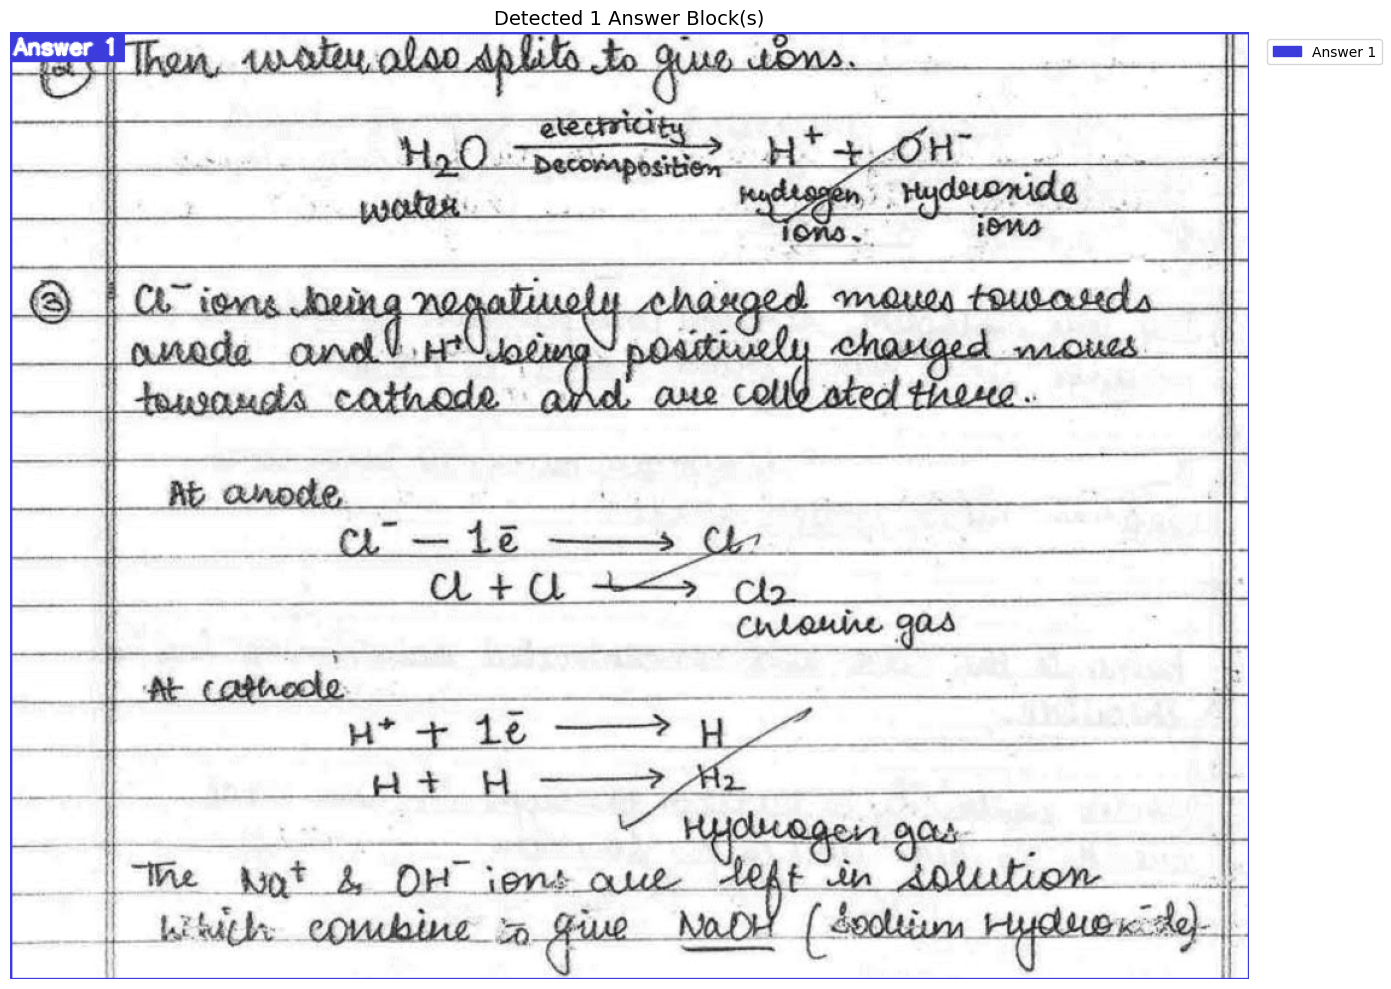

In [ ]:
# Color palette (BGR)
PALETTE = [
    (220,  60,  60), ( 60, 160, 220), ( 60, 200,  80),
    (220, 150,  40), (160,  60, 220), ( 40, 200, 200),
    (220,  60, 160), (100, 180,  40), ( 40, 100, 220),
    (200, 120,  40),
]

def annotate_image(img, blocks):
    annotated  = img.copy()
    h, w       = annotated.shape[:2]
    font       = cv2.FONT_HERSHEY_SIMPLEX
    thickness  = max(2, w // 400)
    font_scale = max(0.6, w / 1800)

    for idx, (x1, y1, x2, y2) in enumerate(blocks):
        color = PALETTE[idx % len(PALETTE)]
        cv2.rectangle(annotated, (x1, y1), (x2, y2), color, thickness)

        label           = f"Answer {idx + 1}"
        (tw, th), base  = cv2.getTextSize(label, font, font_scale, thickness)
        label_y         = max(y1 - 6, th + 4)

        cv2.rectangle(annotated,
                    (x1, label_y - th - 4),
                    (x1 + tw + 6, label_y + base),
                    color, cv2.FILLED)
        cv2.putText(annotated, label, (x1 + 3, label_y),
                    font, font_scale, (255, 255, 255), thickness, cv2.LINE_AA)

    return annotated


annotated = annotate_image(img, blocks)


plt.figure(figsize=(14, 10))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Detected {len(blocks)} Answer Block(s)", fontsize=14)
plt.axis("off")

patches = [
    mpatches.Patch(
        color=[c/255 for c in PALETTE[i % len(PALETTE)][::-1]],
        label=f"Answer {i+1}"
    )
    for i in range(len(blocks))
]
plt.legend(handles=patches, bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

In [7]:
json_path = OUTPUT_PATH.replace(".png", "_results.json")

with open(json_path, "w", encoding="utf-8") as f:
    json.dump(results, f, indent=2, ensure_ascii=False)

print(f"Results saved → {json_path}")
print(json.dumps(results, indent=2))

Results saved → annotated_sheet_results.json
[
  {
    "block": 1,
    "bbox": {
      "x1": 0,
      "y1": 0,
      "x2": 1024,
      "y2": 783
    },
    "text": "(@> | Thea, Anau ola db Lily to We won\n| me amet\n| > a+U+3 a |.\n4. NE se Ee I Secor a2 hisfem 2-9: :\n\u2014 1 ee sania \u2018 enim (dein tysuo nde"
  }
]
